In [ ]:
!pip install scipy

In [2]:
import numpy as np
from scipy.integrate import odeint
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time
import imageio.v2 as imageio

def rand_initial_values(N, rmin, rmax, vmin, vmax, mmin, mmax):
  r = rmin + (rmax - rmin)*np.random.rand(N, 2)
  v = vmin + (vmax - vmin)*np.random.rand(N, 2)
  m = mmin + (mmax - mmin)*np.random.rand(N, 1)
  return r, v, m

def plot_initial_distr(r, v, rxmin, rxmax, rymin, rymax, figsize = (3, 3)):
  fig = plt.figure(figsize=figsize)
  plt.title('Initial positions')
  plt.xlim([rxmin, rxmax])
  plt.ylim([rymin, rymax])
  plt.xlabel('x')
  plt.ylabel('y')
  plt.quiver(r[:,0], r[:, 1], v[:,0], v[:, 1], scale=0.25, scale_units='xy') #, scale_units='xy')
  plt.scatter(r[:,0], r[:,1], marker='o')
  plt.scatter(r[:,0][0], r[:,1][0], marker='o', c = 'r')
  #plt.plot(r[:,0], r[:, 1], 'o')
  plt.show()

def R_derivatives(R, t, m):
  #x[0] = R, x[1] = dR/dt
  #6.6743 × 10-11 м3 кг-1 с-2
  G = 6.6743 * 10**(-11)
  d2Rdtx = np.zeros(N)
  d2Rdty = np.zeros(N)
  for i in range(N):
    for j in range(N):
      if i == j:
        continue
      if R[i] == R[j] and R[i+N]==R[j+N]:
        continue
      d2Rdtx[i] = d2Rdtx[i] + m[j]*(R[j] - R[i])/(((R[j] - R[i])**2 + (R[j+N] - R[i+N])**2)**0.5)**3
      d2Rdty[i] = d2Rdty[i] + m[j]*(R[j+N] - R[i+N])/(((R[j] - R[i])**2 + (R[j+N] - R[i+N])**2)**0.5)**3
  d2Rdtx = d2Rdtx*G
  d2Rdty = d2Rdty*G
  return np.concatenate((R[2*N:3*N], R[3*N:], d2Rdtx, d2Rdty))

def visualize_solution(positions_x, positions_y, rxmin, rxmax, rymin, rymax,
                                        t, fps = 1, filename = 'gif1.gif', figsize = (4, 4)):
  with imageio.get_writer(filename, mode='I', fps = fps) as writer:
    for i in range(t.shape[0]):
      fig = plt.figure(figsize=figsize)
      plt.xlabel('x')
      plt.ylabel('y')
      plt.xlim([rxmin, rxmax])
      plt.ylim([rymin, rymax])
      plt.plot(positions_x[1:,i], positions_y[1:,i], 'o')
      plt.scatter(positions_x[:,i][0], positions_y[:,i][0], marker ='o', c = 'r')
      plt.savefig('temp_plot.png', dpi=fig.dpi)
      writer.append_data(imageio.imread('temp_plot.png'))
      plt.close()

def visualize_solution_ell(positions_x, positions_y, rxmin, rxmax, rymin, rymax,a, b, cx, cy,
                                        t, fps = 1, filename = 'gif1.gif', figsize = (4, 4), phi0=0):
  with imageio.get_writer(filename, mode='I', fps = fps) as writer:
    for i in range(t.shape[0]):
      # fig = plt.figure(figsize=figsize)
      fig, ax = plt.subplots(1,1, figsize = figsize)
      plt.xlabel('x')
      plt.ylabel('y')
      plt.xlim([rxmin, rxmax])
      plt.ylim([rymin, rymax])
      plt.plot(positions_x[1:,i], positions_y[1:,i], 'o')
      plt.scatter(positions_x[:,i][0], positions_y[:,i][0], marker ='o', c = 'r')
      ell = matplotlib.patches.Ellipse((cx, cy), 2*a, 2*b, angle = phi0, facecolor='none', edgecolor='blue')
      ax.add_patch(ell)
      plt.savefig('temp_plot.png', dpi=fig.dpi)
      writer.append_data(imageio.imread('temp_plot.png'))
      plt.close()

def visualize_solution_planets(positions_x, positions_y, rxmin, rxmax, rymin, rymax, a, b, cx, cy,
                                        t, fps = 1, filename = 'gif1.gif', figsize = (4, 4)):
  #ell = matplotlib.patches.Ellipse((cx, cy), 2*a, 2*b, facecolor='none', edgecolor='blue')
  with imageio.get_writer(filename, mode='I', fps = fps) as writer:
    for i in range(t.shape[0]):
      #fig = plt.figure(figsize=(4, 4))
      fig, ax = plt.subplots(1,1, figsize = figsize)
      plt.xlabel('x')
      plt.ylabel('y')
      plt.xlim([rxmin, rxmax])
      plt.ylim([rymin, rymax])
      plt.plot(positions_x[1:,i], positions_y[1:,i], 'o')
      plt.scatter(positions_x[:,i][0], positions_y[:,i][0], marker ='o', c = 'r')
      plt.scatter([-np.max(positions_x[1])], [60], marker ='o', c = 'r')
      #print(np.max(positions_x[1]))
      ell = matplotlib.patches.Ellipse((cx, cy), 2*a, 2*b, facecolor='none', edgecolor='blue')
      #fig.patches.extend([ell])
      ax.add_patch(ell)
      plt.savefig('temp_plot.png', dpi=fig.dpi)
      writer.append_data(imageio.imread('temp_plot.png'))
      plt.close()

**Тест 1:** N = 2, первая точка имеет массу 1,35*10^12 кг и покоится, вторая точка с массой 10 кг движется в гравитационном поле первой точки со скоростью, перпендикулярной полю, и, поэтому закручивается вокруг первой точки.

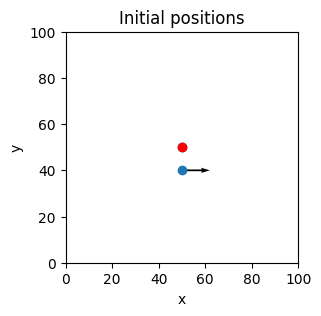

In [ ]:
N = 2
r = np.array([[50,50], [50, 40]])
v = np.array([[0, 0], [3, 0]])
plot_initial_distr(r, v, 0, 100, 0, 100)
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]
# rx_mesh = np.meshgrid(r[:,0], r[:,0])
# ry_mesh = np.meshgrid(r[:,1], r[:,1])
m = [1.35*10**12, 10]
ics = np.concatenate((rx, ry, vx, vy))
#print(ics)
t = np.arange(0, 100, 1)
# rx = [50, 50]
# ry = [50, 40]
res = odeint(R_derivatives, ics, t, args=(m,)).T
positions_x = res[0:N]
positions_y = res[N:2*N]
velocities_x = res[2*N:3*N]
velocities_y = res[3*N:]

#Theoretical ellipse
G = 6.6743 * 10**(-11)
e = (( vx[1]**2*((rx[1]-rx[0])**2+(ry[1]-ry[0])**2)**0.5 )/(G*m[0]) - 1)
p = vx[1]**2*((rx[1]-rx[0])**2+(ry[1]-ry[0])**2)/(G*m[0])
a = p/(1-e**2)
#фокус
f1 = a*e
b = a*(1-e**2)**0.5
x0 = rx[0]
y0 = ry[0] + f1

visualize_solution_ell(positions_x, positions_y, 20, 80, 20, 80 , a, b, x0, y0, t, fps = 6, filename = 'gif1.gif', phi0=-90)

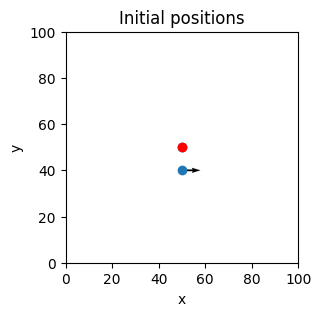

In [ ]:
N = 2
r = np.array([[50,50], [50, 40]])
v = np.array([[0, 0], [2, 0]])
plot_initial_distr(r, v, 0, 100, 0, 100)
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]
# rx_mesh = np.meshgrid(r[:,0], r[:,0])
# ry_mesh = np.meshgrid(r[:,1], r[:,1])
m = [1.35*10**12, 10]
ics = np.concatenate((rx, ry, vx, vy))
#print(ics)
t = np.arange(0, 200, 1)
# rx = [50, 50]
# ry = [50, 40]
res = odeint(R_derivatives, ics, t, args=(m,)).T
positions_x = res[0:N]
positions_y = res[N:2*N]
velocities_x = res[2*N:3*N]
velocities_y = res[3*N:]

#Theoretical ellipse
G = 6.6743 * 10**(-11)
e = (( vx[1]**2*((rx[1]-rx[0])**2+(ry[1]-ry[0])**2)**0.5 )/(G*m[0]) - 1)
p = vx[1]**2*((rx[1]-rx[0])**2+(ry[1]-ry[0])**2)/(G*m[0])
a = p/(1-e**2)
#фокус
f1 = a*e
b = a*(1-e**2)**0.5
x0 = rx[0]
y0 = ry[0] + f1
visualize_solution_ell(positions_x, positions_y, 20, 80, 20, 80, a, b, x0, y0, t, fps = 6, filename = 'gif2.gif', phi0 = -90)

-0.5560638624330696
6.426471458802434
5.3412947097168
-3.5735285411975646


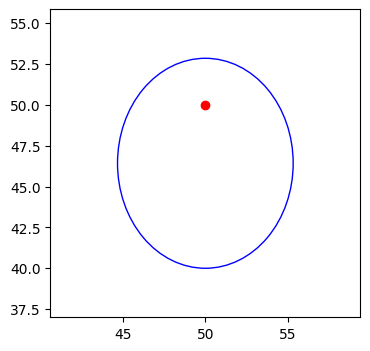

In [ ]:
G = 6.6743 * 10**(-11)
e = (( vx[1]**2*((rx[1]-rx[0])**2+(ry[1]-ry[0])**2)**0.5 )/(G*m[0]) - 1)
p = vx[1]**2*((rx[1]-rx[0])**2+(ry[1]-ry[0])**2)/(G*m[0])
a = p/(1-e**2)
#фокус
f1 = a*e
b = a*(1-e**2)**0.5
x0 = rx[0]
y0 = ry[0] + f1
fig, ax = plt.subplots(1,1, figsize = (4, 4))
ell = matplotlib.patches.Ellipse((x0, y0), 2*a, 2*b, facecolor='none', edgecolor='blue', angle = -90)
ax.add_patch(ell)
ax.set_xlim([x0 - a - 3, x0 + a + 3])
ax.set_ylim([y0 - a - 3, y0 + a + 3])
ax.scatter(rx[0], ry[0], marker = 'o', c = 'r')
print(e)
print(a)
print(b)
print(f1)

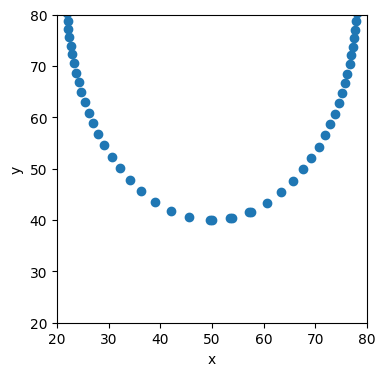

In [ ]:
fig = plt.figure(figsize=(4, 4))
plt.xlabel('x')
plt.ylabel('y')
plt.xlim([20, 80])
plt.ylim([20, 80])
plt.plot(positions_x[1], positions_y[1], 'o')

In [ ]:
def R_derivatives2(R, t, m, rx, ry):
  #x[0] = R, x[1] = dR/dt
  #6.6743 × 10-11 м3 кг-1 с-2
  G = 6.6743 * 10**(-11)
  d2Rdtx = G*m[0]*(rx[0] - R[0])/(((rx[0] - R[0])**2 + (ry[0] - R[1])**2)**0.5)**3
  d2Rdty = G*m[0]*(ry[0] - R[1])/(((rx[0] - R[0])**2 + (ry[0] - R[1])**2)**0.5)**3
  return [R[2], R[3], d2Rdtx, d2Rdty]


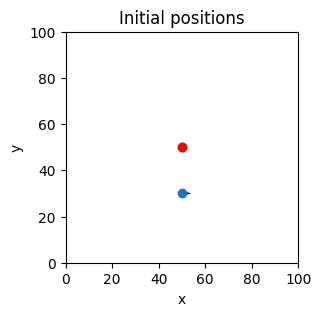

In [ ]:
N = 2
r = np.array([[50,50], [50, 30]])
v = np.array([[0, 0], [1, 0]])
plot_initial_distr(r, v, 0, 100, 0, 100)
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]
# rx_mesh = np.meshgrid(r[:,0], r[:,0])
# ry_mesh = np.meshgrid(r[:,1], r[:,1])
m = [1.35*10**12, 10]
#ics_x = np.concatenate((rx, vx))
ics = [rx[1], ry[1], vx[1], vy[1]]
#print(ics)
t = np.arange(0, 100, 1)
# rx = [50, 50]
# ry = [50, 40]
positions_x, positions_y, velocities_x, velocities_y = odeint(R_derivatives2, ics, t, args=(m, )).T
# positions_x = res_x[0:N]
# velocities_x = res_x[N:]

# ics_y = np.concatenate((ry, vy))
# # res_y = odeint(R_derivatives, ics_y, t).T
# res_y = odeint(R_derivatives, ics_y, t, args=(m, rx, ry, ry[0])).T
# positions_y = res_y[0:N]
# velocities_y = res_y[N:]

# visualize_solution(positions_x, positions_y, 20, 80, 20, 80, t, fps = 6, filename = 'gif2.gif')

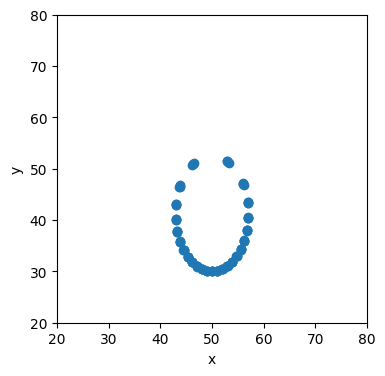

In [ ]:
fig = plt.figure(figsize=(4, 4))
plt.xlabel('x')
plt.ylabel('y')
plt.xlim([20, 80])
plt.ylim([20, 80])
plt.plot(positions_x, positions_y, 'o')

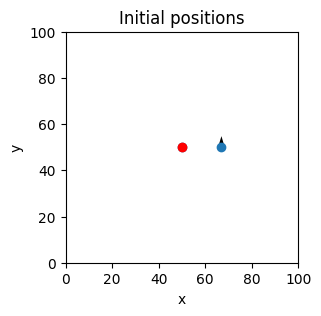

In [ ]:
N = 2
r = np.array([[50,50], [67, 50]])
v = np.array([[0, 0], [0, 1.2]])
plot_initial_distr(r, v, 0, 100, 0, 100)
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]
# rx_mesh = np.meshgrid(r[:,0], r[:,0])
# ry_mesh = np.meshgrid(r[:,1], r[:,1])
m = [1.35*10**12, 10]
ics_x = np.concatenate((rx, ry, vx, vy))
#print(ics)
t = np.arange(0, 100, 1)
# rx = [50, 50]
# ry = [50, 40]
res_x = odeint(R_derivatives, ics_x, t, args=(m, )).T
positions_x = res_x[0:N]
velocities_x = res_x[N:]


visualize_solution(positions_x, positions_y, 20, 80, 20, 80, t, fps = 6, filename = 'gif3.gif')

**Тест 2**. N = 4. Начальные положения, скорости и массы заданы случайным образом.


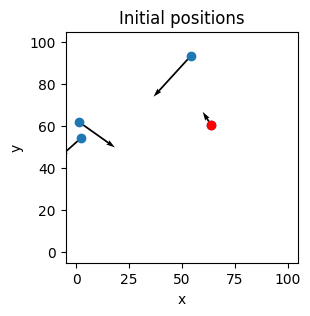

<ipython-input-1-612a1a0e1e53>:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  d2Rdtx[i] = d2Rdtx[i] + m[j]*(R[j] - R[i])/(((R[j] - R[i])**2 + (R[j+N] - R[i+N])**2)**0.5)**3
<ipython-input-1-612a1a0e1e53>:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  d2Rdty[i] = d2Rdty[i] + m[j]*(R[j+N] - R[i+N])/(((R[j] - R[i])**2 + (R[j+N] - R[i+N])**2)**0.5)**3


In [ ]:
rmin = 0
rmax = 100
vmin = -5
vmax = 5
mmin = 1
mmax = 5000000

N = 4
r, v, m = rand_initial_values(N, rmin, rmax, vmin, vmax, mmin, mmax)
plot_initial_distr(r, v, rmin - 5, rmax + 5, rmin - 5, rmax + 5)
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]

ics = np.concatenate((rx, ry, vx, vy))
t = np.arange(0, 100, 1)
res = odeint(R_derivatives, ics, t, args=(m,)).T
positions_x = res[0:N]
positions_y = res[N:2*N]
velocities_x = res[2*N:3*N]
velocities_y = res[3*N:]

visualize_solution(positions_x, positions_y, rmin - 20, rmax + 20, rmin - 20, rmax + 20, t, fps = 4, filename = 'gif21.gif')

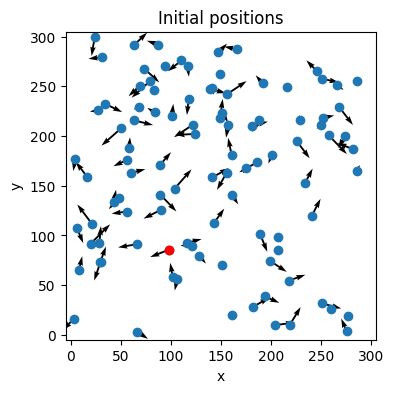

<ipython-input-1-612a1a0e1e53>:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  d2Rdtx[i] = d2Rdtx[i] + m[j]*(R[j] - R[i])/(((R[j] - R[i])**2 + (R[j+N] - R[i+N])**2)**0.5)**3
<ipython-input-1-612a1a0e1e53>:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  d2Rdty[i] = d2Rdty[i] + m[j]*(R[j+N] - R[i+N])/(((R[j] - R[i])**2 + (R[j+N] - R[i+N])**2)**0.5)**3


In [ ]:
rmin = 0
rmax = 300
vmin = -5
vmax = 5
mmin = 1
mmax = 5000000

N = 100
r, v, m = rand_initial_values(N, rmin, rmax, vmin, vmax, mmin, mmax)
plot_initial_distr(r, v, rmin - 5, rmax + 5, rmin - 5, rmax + 5, figsize=(4,4))
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]

ics = np.concatenate((rx, ry, vx, vy))
t = np.arange(0, 100, 1)
res = odeint(R_derivatives, ics, t, args=(m,)).T
positions_x = res[0:N]
positions_y = res[N:2*N]
velocities_x = res[2*N:3*N]
velocities_y = res[3*N:]

visualize_solution(positions_x, positions_y, rmin - 20, rmax + 20, rmin - 20, rmax + 20, t, fps = 4, filename = 'gif31.gif', figsize=(5, 5))

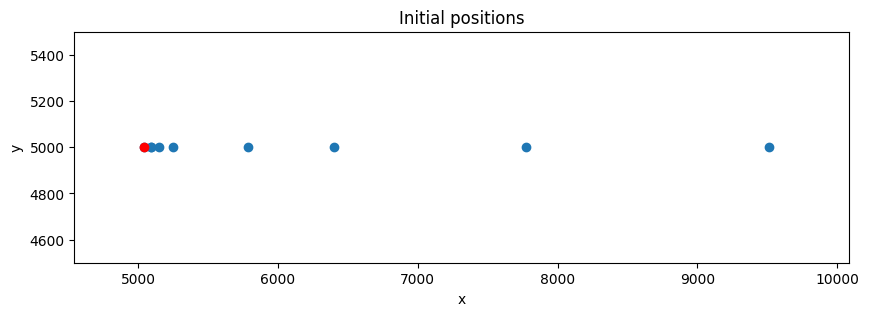

In [ ]:
N = 9
# Sx ~ 5000*10^6 km
# Sy ~ 50 * 10^6 km
# but we'll divide it by 10^3 and the same with the velocity
#coordinates of the sun
# Sx = 5000*10**3
# Sy = 50*10**3
cx = 5000*10**3
cy = 5000*10**3
a = 4514.953*10**3
e = 0.0097
b = a * (1 - e**2)**0.5
Sx = cx + a*e
Sy = cy
r = np.array([
    [Sx, Sy], #Sun
    [Sx + 45.9*10**3, Sy], #Mercury
    [Sx + 107.476*10**3, Sy], #Venus
    [Sx + 47.098*10**3, Sy],#Earth
    [Sx + 206.665*10**3, Sy],#Mars
    [Sx + 740.595*10**3, Sy],#Jupiter
    [Sx + 1357.554*10**3, Sy],#Saturne
    [Sx + 2732.696*10**3, Sy],#Uranus
    [Sx + 4471.050*10**3, Sy] #Neptune
    ])
v = np.array([
    [0,0], #Sun
    [0, 0.0566], #Mercury
    [0,0.035], #Venus
    [0,0.03],#Earth
    [0,0.0265],#Mars
    [0,0.01372],#Jupiter
    [0,0.01014],#Saturne
    [0,0.00713],#Uranus
    [0,0.00547 ] #Neptune
    ])
plot_initial_distr(r/10**3, v*100, Sx/10**3 - 500, Sx*2/10**3, Sy/10**3 - 500, Sy/10**3 + 500, figsize = (10, 3))
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]
# rx_mesh = np.meshgrid(r[:,0], r[:,0])
# ry_mesh = np.meshgrid(r[:,1], r[:,1])
m = [
    199*10**10, #Sun
    0.33*10**6, #Mercury
    4.87*10**6, #Venus
    5.97*10**6,#Earth
    0.642*10**6,#Mars
    1898*10**6,#Jupiter
    568*10**6,#Saturne
    86.8*10**6,#Uranus
    102*10**6 #Neptune
]
ics = np.concatenate((rx, ry, vx, vy))
#print(ics)
t = np.arange(0, 5*31.536*10**6, 5*86400)
# rx = [50, 50]
# ry = [50, 40]
res = odeint(R_derivatives, ics, t, args=(m,)).T
positions_x = res[0:N]
positions_y = res[N:2*N]
velocities_x = res[2*N:3*N]
velocities_y = res[3*N:]

visualize_solution_planets(positions_x/10**3, positions_y/10**3, 0, Sx*2/10**3, 0, Sx*2/10**3,
                            a/10**3, b/10**3, cx/10**3, cy/10**3, t, fps = 6, filename = 'gif10.gif', figsize = (12,12))

In [ ]:
visualize_solution_planets(positions_x/10**3, positions_y/10**3, 0, Sx*2/10**3, 0, Sx*2/10**3,
                            a/10**3, b/10**3, cx/10**3, cy/10**3, t, fps = 6, filename = 'gif10.gif', figsize = (12,12))

**Меркурий**

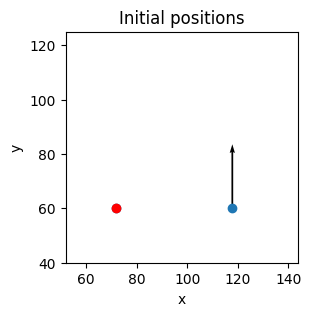

117829.28997291412
2850.8000497494913


In [16]:
N = 2
cx = 60*10**3
cy = 60*10**3
a = 57.909*10**3
e = 0.206
b = a * (1 - e**2)**0.5
Sx = cx + a*e
Sy = cy
r = np.array([
    [Sx, Sy], #Sun
    [Sx + 45.9*10**3, Sy] #Mercury
])
v = np.array([
    [0,0], #Sun
    #[0, 0.0566] #Mercury
    [0, 0.05897] #Mercury
])
plot_initial_distr(r/10**3, v*100, Sx/10**3 - 20, Sx*2/10**3, Sy/10**3 - 20, Sy*2/10**3 + 5)
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]
# rx_mesh = np.meshgrid(r[:,0], r[:,0])
# ry_mesh = np.meshgrid(r[:,1], r[:,1])
m = [
    199*10**10, #Sun
    0.33*10**6 #Mercury
]

ics = np.concatenate((rx, ry, vx, vy))
#print(ics)
t = np.arange(0, 31.536*10**6, 86400)
# rx = [50, 50]
# ry = [50, 40]
res = odeint(R_derivatives, ics, t, args=(m,)).T
positions_x = res[0:N]
positions_y = res[N:2*N]
velocities_x = res[2*N:3*N]
velocities_y = res[3*N:]
# ics_x = np.concatenate((rx, vx))
# #print(ics)
# t = np.arange(0, 31.536*10**6, 86400)
# res_x = odeint(R_derivatives, ics_x, t, args=(m, rx, ry)).T
# positions_x = res_x[0:N]
# velocities_x = res_x[N:]

print(np.max(positions_x[1]))
print(np.min(positions_x[1]))

# ics_y = np.concatenate((ry, vy))
# # res_y = odeint(R_derivatives, ics_y, t).T
# res_y = odeint(R_derivatives, ics_y, t, args=(m, rx, ry)).T
# positions_y = res_y[0:N]
# velocities_y = res_y[N:]

visualize_solution_planets(positions_x/10**3, positions_y/10**3, 0, Sx*2/10**3 + 20, 0, Sx*2/10**3 + 20, a/10**3, b/10**3, cx/10**3, cy/10**3,
                   t, fps = 6, filename = 'gif11.gif')

In [ ]:
print(Sx)
print(np.max(positions_y[1]))
print(np.min(positions_y[1]))

71929.254
110304.38476761674
9693.371720238478


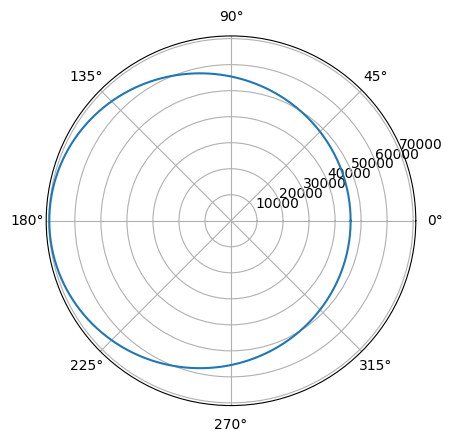

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

phi = np.linspace(0, 2*np.pi, 360)
# e = 0.8
# a = 3
a = 57.909*10**3
e = 0.206
p = a*(1-e**2)
#phi0 = -np.pi/2
phi0 = 0
r = p/(1+e*np.cos(phi-phi0))

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(phi, r)
# fig = plt.figure(figsize=(4, 4))
# plt.xlabel('x')
# plt.ylabel('y')
# plt.xlim([20, 80])
# plt.ylim([20, 80])
# plt.plot(positions_x[1], positions_y[1], 'o')

In [ ]:
a = 1;
b = 5;
N = 10;

def odefcn(z,x):
  dzdx1 = z[1]
  dzdx2 = -1/x*z[1] - 4/(x**2)*z[0] - 1/(x**2)
  return [dzdx1, dzdx2]
# % x1'(t) = 2x1 - 1;
# %x2'(t) = 3x1 + 2x2 + 1;
# %z1' = z2;
# %z2' = -1/x*z1' - 4/x^2*z1-1/x^2
#xspan = [a b]
x = np.linspace(a, b, 100)
z0 = [0, 1]
z1, _= odeint(odefcn, z0, x).T
#[x,z] = ode45(@(x,z) odefcn(x,z), xspan, z0)
print(z1)
#print(z)


[ 0.          0.03878368  0.07438323  0.10689819  0.13644258  0.16313993
  0.18711935  0.20851261  0.22745192  0.24406824  0.25849008  0.27084258
  0.28124689  0.28981972  0.29667309  0.30191417  0.3056452   0.30796355
  0.30896172  0.3087275   0.30734408  0.3048902   0.30144032  0.29706482
  0.29183012  0.28579893  0.27903037  0.27158019  0.26350092  0.25484205
  0.24565018  0.23596917  0.22584031  0.21530246  0.20439215  0.19314376
  0.18158959  0.16976004  0.15768365  0.14538726  0.13289605  0.12023371
  0.10742247  0.09448317  0.08143541  0.06829755  0.05508682  0.04181936
  0.02851033  0.01517388  0.00182331 -0.01152896 -0.0248713  -0.03819285
 -0.05148345 -0.06473361 -0.07793448 -0.09107781 -0.10415592 -0.11716165
 -0.13008833 -0.1429298  -0.15568031 -0.16833455 -0.18088761 -0.19333494
 -0.20567235 -0.21789598 -0.23000231 -0.24198807 -0.25385031 -0.26558631
 -0.27719364 -0.28867006 -0.30001359 -0.31122242 -0.32229497 -0.33322982
 -0.34402575 -0.35468167 -0.36519667 -0.37556999 -0

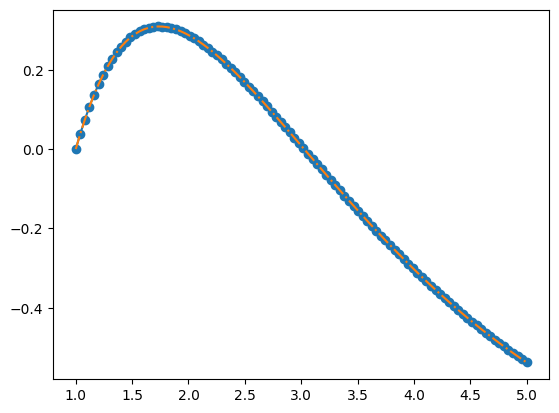

In [ ]:
z2 = 1/2*np.sin(2*np.log(x)) + 1/4*np.cos(2*np.log(x)) - 1/4;

fig = plt.figure();
#plot(x,z(:,1),'-o',x,z(:,2),'-.');
plt.plot(x, z1,'-o',x,z2, '-.');
#plt.legend('ode45', 'analytical');


**Алгоритм Верле**

In [3]:
def calc_acceleration(rx, ry, m):
  #6.6743 × 10-11 м3 кг-1 с-2
  G = 6.6743 * 10**(-11)
  ax = np.zeros(N)
  ay = np.zeros(N)
  for i in range(N):
    for j in range(N):
      if i == j:
        continue
      if rx[i] == ry[j] and ry[i]==ry[j]:
        continue
      ax[i] = ax[i] + m[j]*(rx[j] - rx[i])/(((rx[j] - rx[i])**2 + (ry[j] - ry[i])**2)**0.5)**3
      ay[i] = ay[i] + m[j]*(ry[j] - ry[i])/(((rx[j] - rx[i])**2 + (ry[j] - ry[i])**2)**0.5)**3
  ax = ax*G
  ay = ay*G
  return ax, ay

def Verlet(rx, ry, vx, vy, ax, ay, dt, m):
  rx_n1 = rx + vx*dt + ax/2*dt**2
  ry_n1 = ry + vy*dt + ay/2*dt**2

  ax_n1, ay_n1 = calc_acceleration(rx_n1, ry_n1, m)
  vx_n1 = vx + 1/2*(ax+ax_n1)*dt
  vy_n1 = vy + 1/2*(ay+ay_n1)*dt
  return rx_n1, ry_n1, vx_n1, vy_n1, ax_n1, ay_n1

def solve_ode(N, rx0, ry0, vx0, vy0, m, t):
  rx = np.zeros((N, t.shape[0]))
  ry = np.zeros((N, t.shape[0]))
  vx = np.zeros((N, t.shape[0]))
  vy = np.zeros((N, t.shape[0]))
  ax, ay = calc_acceleration(rx0, ry0, m)
  rx[:,0] = rx0
  ry[:,0] = ry0
  vx[:,0] = vx0
  vy[:,0] = vy0
  for i in range(1, t.shape[0]):
    rx[:,i], ry[:,i], vx[:,i], vy[:,i], ax, ay = Verlet(rx[:,i-1], ry[:,i-1], vx[:,i-1], vy[:,i-1],
                                                                              ax, ay, t[i] - t[i-1], m)
  return rx, ry, vx, vy


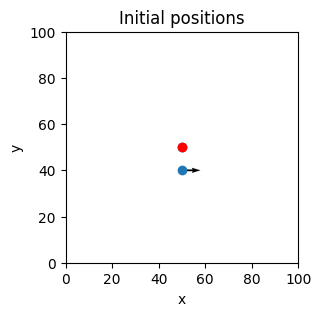

(1000,)


In [18]:
N = 2
r = np.array([[50,50], [50, 40]])
v = np.array([[0, 0], [2, 0]])
plot_initial_distr(r, v, 0, 100, 0, 100)
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]

m = [1.35*10**12, 10]

#print(ics)
t = np.arange(0, 100, 0.1)
# rx = [50, 50]
# ry = [50, 40]
print(t.shape)
positions_x, positions_y, velocities_x, velocities_y = solve_ode(N, rx, ry, vx, vy, m, t)

#visualize_solution(positions_x, positions_y, 20, 80, 20, 80, t, fps = 6, filename = 'gif5.gif')

In [19]:
#theoretical ellips
G = 6.6743 * 10**(-11)
e = (( vx[1]**2*((rx[1]-rx[0])**2+(ry[1]-ry[0])**2)**0.5 )/(G*m[0]) - 1)
p = vx[1]**2*((rx[1]-rx[0])**2+(ry[1]-ry[0])**2)/(G*m[0])
a = p/(1-e**2)
#фокус
f1 = a*e
b = a*(1-e**2)**0.5
x0 = rx[0]
y0 = ry[0] + f1
# fig, ax = plt.subplots(1,1, figsize = (4, 4))
# ell = matplotlib.patches.Ellipse((x0, y0), 2*a, 2*b, facecolor='none', edgecolor='blue', angle = -90)
# ax.add_patch(ell)
# ax.set_xlim([x0 - a - 3, x0 + a + 3])
# ax.set_ylim([y0 - a - 3, y0 + a + 3])
# ax.scatter(rx[0], ry[0], marker = 'o', c = 'r')

visualize_solution_ell(positions_x, positions_y, 20, 80, 20, 80, a, b, x0, y0, t, fps = 12, filename = 'gif5.gif', phi0=-90)

In [ ]:
fig = plt.figure(figsize=(4, 4))
plt.xlabel('x')
plt.ylabel('y')
plt.xlim([20, 80])
plt.ylim([20, 80])
plt.plot(positions_x[1], positions_y[1], 'o')

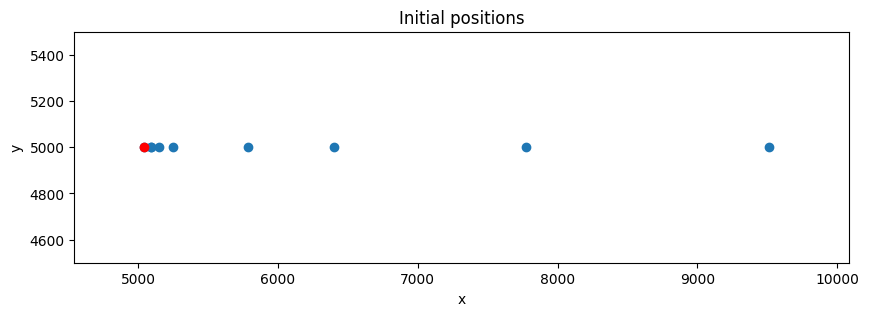

In [ ]:
N = 9
# Sx ~ 5000*10^6 km
# Sy ~ 50 * 10^6 km
# but we'll divide it by 10^3 and the same with the velocity
#coordinates of the sun
# Sx = 5000*10**3
# Sy = 50*10**3
cx = 5000*10**3
cy = 5000*10**3
a = 4514.953*10**3
e = 0.0097
b = a * (1 - e**2)**0.5
Sx = cx + a*e
Sy = cy
r = np.array([
    [Sx, Sy], #Sun
    [Sx + 45.9*10**3, Sy], #Mercury
    [Sx + 107.476*10**3, Sy], #Venus
    [Sx + 47.098*10**3, Sy],#Earth
    [Sx + 206.665*10**3, Sy],#Mars
    [Sx + 740.595*10**3, Sy],#Jupiter
    [Sx + 1357.554*10**3, Sy],#Saturne
    [Sx + 2732.696*10**3, Sy],#Uranus
    [Sx + 4471.050*10**3, Sy] #Neptune
    ])
v = np.array([
    [0,0], #Sun
    [0, 0.0566], #Mercury
    [0,0.035], #Venus
    [0,0.03],#Earth
    [0,0.0265],#Mars
    [0,0.01372],#Jupiter
    [0,0.01014],#Saturne
    [0,0.00713],#Uranus
    [0,0.00547 ] #Neptune
    ])
plot_initial_distr(r/10**3, v*100, Sx/10**3 - 500, Sx*2/10**3, Sy/10**3 - 500, Sy/10**3 + 500, figsize = (10, 3))
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]
# rx_mesh = np.meshgrid(r[:,0], r[:,0])
# ry_mesh = np.meshgrid(r[:,1], r[:,1])
m = [
    199*10**10, #Sun
    0.33*10**6, #Mercury
    4.87*10**6, #Venus
    5.97*10**6,#Earth
    0.642*10**6,#Mars
    1898*10**6,#Jupiter
    568*10**6,#Saturne
    86.8*10**6,#Uranus
    102*10**6 #Neptune
]
ics = np.concatenate((rx, ry, vx, vy))
#print(ics)
t = np.arange(0, 5*31.536*10**6, 86400)
# rx = [50, 50]
# ry = [50, 40]
positions_x, positions_y, velocities_x, velocities_y = solve_ode(N, rx, ry, vx, vy, m, t)

visualize_solution_planets(positions_x/10**3, positions_y/10**3, 0, Sx*2/10**3, 0, Sx*2/10**3,
                            a/10**3, b/10**3, cx/10**3, cy/10**3, t, fps = 6, filename = 'gif210.gif', figsize = (12,12))

In [ ]:
!pip install numba

In [20]:
from numba import njit

@njit
def calc_acceleration_fast(rx, ry, m):
  #6.6743 × 10-11 м3 кг-1 с-2
  G = 6.6743 * 10**(-11)
  ax = np.zeros(N)
  ay = np.zeros(N)
  for i in range(N):
    for j in range(N):
      if i == j:
        continue
      if rx[i] == ry[j] and ry[i]==ry[j]:
        continue
      ax[i] = ax[i] + m[j]*(rx[j] - rx[i])/(((rx[j] - rx[i])**2 + (ry[j] - ry[i])**2)**0.5)**3
      ay[i] = ay[i] + m[j]*(ry[j] - ry[i])/(((rx[j] - rx[i])**2 + (ry[j] - ry[i])**2)**0.5)**3
  ax = ax*G
  ay = ay*G
  return ax, ay

@njit
def Verlet_fast(rx, ry, vx, vy, ax, ay, dt, m):
  rx_n1 = rx + vx*dt + ax/2*dt**2
  ry_n1 = ry + vy*dt + ay/2*dt**2

  ax_n1, ay_n1 = calc_acceleration_fast(rx_n1, ry_n1, m)
  vx_n1 = vx + 1/2*(ax+ax_n1)*dt
  vy_n1 = vy + 1/2*(ay+ay_n1)*dt
  return rx_n1, ry_n1, vx_n1, vy_n1, ax_n1, ay_n1
@njit
def solve_ode_fast(rx0, ry0, vx0, vy0, m, t):
  rx = np.zeros((N, t.shape[0]))
  ry = np.zeros((N, t.shape[0]))
  vx = np.zeros((N, t.shape[0]))
  vy = np.zeros((N, t.shape[0]))
  ax, ay = calc_acceleration_fast(rx0, ry0, m)
  rx[:,0] = rx0
  ry[:,0] = ry0
  vx[:,0] = vx0
  vy[:,0] = vy0
  for i in range(1, t.shape[0]):
    rx[:,i], ry[:,i], vx[:,i], vy[:,i], ax, ay = Verlet_fast(rx[:,i-1], ry[:,i-1], vx[:,i-1], vy[:,i-1],
                                                                              ax, ay, t[i] - t[i-1], m)
  return rx, ry, vx, vy


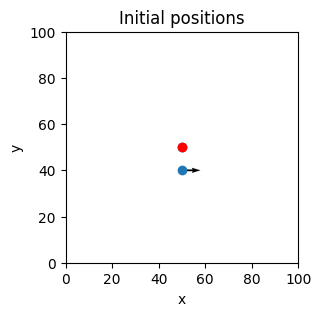

(1000,)


In [21]:
N = 2
r = np.array([[50,50], [50, 40]])
v = np.array([[0, 0], [2, 0]])
plot_initial_distr(r, v, 0, 100, 0, 100)
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]

m = np.array([1.35*10**12, 10], dtype = float)

#print(ics)
t = np.arange(0, 100, 0.1)
# rx = [50, 50]
# ry = [50, 40]
print(t.shape)
positions_x, positions_y, velocities_x, velocities_y = solve_ode_fast(rx, ry, vx, vy, m, t)



In [22]:
#theoretical ellips
G = 6.6743 * 10**(-11)
e = (( vx[1]**2*((rx[1]-rx[0])**2+(ry[1]-ry[0])**2)**0.5 )/(G*m[0]) - 1)
p = vx[1]**2*((rx[1]-rx[0])**2+(ry[1]-ry[0])**2)/(G*m[0])
a = p/(1-e**2)
#фокус
f1 = a*e
b = a*(1-e**2)**0.5
x0 = rx[0]
y0 = ry[0] + f1
# fig, ax = plt.subplots(1,1, figsize = (4, 4))
# ell = matplotlib.patches.Ellipse((x0, y0), 2*a, 2*b, facecolor='none', edgecolor='blue', angle = -90)
# ax.add_patch(ell)
# ax.set_xlim([x0 - a - 3, x0 + a + 3])
# ax.set_ylim([y0 - a - 3, y0 + a + 3])
# ax.scatter(rx[0], ry[0], marker = 'o', c = 'r')

visualize_solution_ell(positions_x, positions_y, 20, 80, 20, 80, a, b, x0, y0, t, fps = 12, filename = 'gif7.gif', phi0=-90)

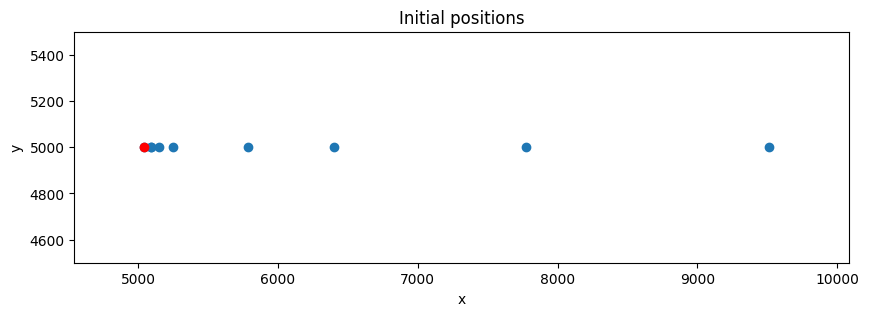

ValueError: unable to broadcast argument 1 to output array
File "<ipython-input-20-be20cc78673c>", line 1, 

In [26]:
N = 9
# Sx ~ 5000*10^6 km
# Sy ~ 50 * 10^6 km
# but we'll divide it by 10^3 and the same with the velocity
#coordinates of the sun
# Sx = 5000*10**3
# Sy = 50*10**3
cx = 5000*10**3
cy = 5000*10**3
a = 4514.953*10**3
e = 0.0097
b = a * (1 - e**2)**0.5
Sx = cx + a*e
Sy = cy
r = np.array([
    [Sx, Sy], #Sun
    [Sx + 45.9*10**3, Sy], #Mercury
    [Sx + 107.476*10**3, Sy], #Venus
    [Sx + 47.098*10**3, Sy],#Earth
    [Sx + 206.665*10**3, Sy],#Mars
    [Sx + 740.595*10**3, Sy],#Jupiter
    [Sx + 1357.554*10**3, Sy],#Saturne
    [Sx + 2732.696*10**3, Sy],#Uranus
    [Sx + 4471.050*10**3, Sy] #Neptune
    ])
v = np.array([
    [0,0], #Sun
    [0, 0.0566], #Mercury
    [0,0.035], #Venus
    [0,0.03],#Earth
    [0,0.0265],#Mars
    [0,0.01372],#Jupiter
    [0,0.01014],#Saturne
    [0,0.00713],#Uranus
    [0,0.00547 ] #Neptune
    ])
plot_initial_distr(r/10**3, v*100, Sx/10**3 - 500, Sx*2/10**3, Sy/10**3 - 500, Sy/10**3 + 500, figsize = (10, 3))
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]
# rx_mesh = np.meshgrid(r[:,0], r[:,0])
# ry_mesh = np.meshgrid(r[:,1], r[:,1])
m = np.array([
    199*10**10, #Sun
    0.33*10**6, #Mercury
    4.87*10**6, #Venus
    5.97*10**6,#Earth
    0.642*10**6,#Mars
    1898*10**6,#Jupiter
    568*10**6,#Saturne
    86.8*10**6,#Uranus
    102*10**6 #Neptune
], dtype=float)
ics = np.concatenate((rx, ry, vx, vy))
#print(ics)
t = np.arange(0, 5*31.536*10**6, 5*86400)
# rx = [50, 50]
# ry = [50, 40]
positions_x, positions_y, velocities_x, velocities_y = solve_ode_fast(rx, ry, vx, vy, m, t)

visualize_solution_planets(positions_x/10**3, positions_y/10**3, 0, Sx*2/10**3, 0, Sx*2/10**3,
                            a/10**3, b/10**3, cx/10**3, cy/10**3, t, fps = 6, filename = 'gif310.gif', figsize = (12,12))